# SPAC-Performance — a quantitative teardown
### Two tapes · CAPM Jensen alpha · HAC inference · survivorship-bias correction · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-NONE-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-MIRAGE-c0392b?style=flat-square)
![SPACs: Busted](https://img.shields.io/badge/SPACs%3A_shortcut_or_rigged%3F-Busted-8b949e?style=flat-square)

Deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — same beats, every claim now carrying its standard error. We test whether SPAC equity delivers a positive Jensen alpha over SPY on two complementary tapes (SPAK ETF 1.92 yrs; surviving de-SPAC basket 4.56 yrs), document the structural-dilution mechanics, and confirm the detector with a synthetic positive control.

> Not investment advice. Real data: Yahoo daily adjusted-close. Methods & sources in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **`In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package (spac_performance)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#1f6feb"
ORANGE = "#e67e22"

from spac_performance import data, strategy as st

STUDY_CACHE = os.path.abspath("../_cache")
SPAK_CACHE = os.path.join(STUDY_CACHE, "spak_daily.parquet")
SPY_CACHE = os.path.join(STUDY_CACHE, "spy_daily.parquet")

def _have_cache():
    return os.path.exists(SPAK_CACHE) and os.path.exists(SPY_CACHE)

HAVE_REAL = _have_cache()

def load_spak():
    prices = data.load_spak_vs_spy(fetch=False, cache_dir=STUDY_CACHE)
    return st.daily_returns(prices), prices

def load_basket():
    prices = data.load_basket_vs_spy(fetch=False, cache_dir=STUDY_CACHE)
    return st.daily_returns(prices), prices

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | SPAK Jensen alpha **-30.69%/yr** (-14.538 bps/day), HAC *t* = **-1.925** — below |2| (1.92-yr window); raw excess *t* = **-2.000** confirms direction. Basket: **-31.52%/yr**, *t* = -1.926 over 4.6 yrs. |
| **Tradability** | `MIRAGE` | SPAK CAGR **-26.14%** vs SPY **+10.26%**; Sharpe -0.930 vs 0.634; max DD -63% vs -23%; SPAK delisted 2022. |
| **SPACs rigged?** | `BUSTED` | ~20% sponsor promote + warrant dilution creates ~12% structural drag at merger (Klausner et al. 2022); basket max DD -86%, survivorship-biased upward. |

> In plain words: SPAC public investors paid for the sponsor's free equity, for the overvalued targets, and for the fee — all embedded in the deal architecture. The price series confirms this in every metric.

## 1 · The claim, steelmanned

Let $r^{f}_t$ be the de-SPAC equity return and $r^{m}_t$ SPY's. Fit the market model

$$ r^{f}_t = \alpha + \beta\, r^{m}_t + \varepsilon_t. $$

The SPAC proposition requires:

- **H₁ (signal).** $\alpha > 0$ — positive Jensen alpha, net of the structural promote and ER, reflected in total-return adjusted prices.
- **H₂ (beats buy-and-hold).** CAGR, Sharpe, and max drawdown all dominate SPY.
- **H₃ (structural fairness).** The sponsor promote is offset by superior deal sourcing and target quality — the dilution is paid back in excess returns.

We find $\hat\alpha \approx -31\%$/yr on SPAK (failing H₁ catastrophically), H₂ fails on all three metrics, and H₃ fails — the promote is not paid back; it compounds against public investors.

## 2 · So what? — what rides on each answer

The interesting failure mode here is not under-power — it is over-performance by the alternative (SPY). With only 1.92 years of SPAK data, the minimum detectable Jensen alpha at |*t*|=2 is roughly ±22%/yr (high idio vol, short window). But the point estimate is **-30.7%/yr** — so extreme it would likely have been statistically significant with even a few more months. We label Signal **None** because the t-stat misses the bar, not because the result is close.

The policy implication is structural: if SPACs reliably underperformed by ~30%/yr in alpha terms, the architecture — not market conditions — explains it.

## 3 · How we'd know — the protocol

**Tape 1 (SPAK).**
- Yahoo daily adjusted-close (total-return) for SPAK and SPY, aligned from SPAK's launch (2020-10-01) to delisting (2022-09-01); 483 common trading days (1.92 years).
- Full-sample OLS market model for $(\alpha, \beta)$; static beta (conservative).
- Newey-West HAC t-stat on the OLS intercept.

**Tape 2 (de-SPAC basket).**
- Equal-weight basket of 9 surviving de-SPACs from RIVN's IPO date (2021-11-11) to 2026-06-12; 1149 common trading days (4.56 years). Survivorship-biased upward.
- Same OLS + HAC protocol.

**Positive control.** Synthetic tape with tunable planted alpha — the detector must recover it when planted, and read near-zero when absent.

Inference bar: |*t*| ≥ 2. SPAK alpha lands at *t* = -1.925; basket at *t* = -1.926.

## 4 · The teardown

### 4a · Tape 1 (SPAK ETF) — market model

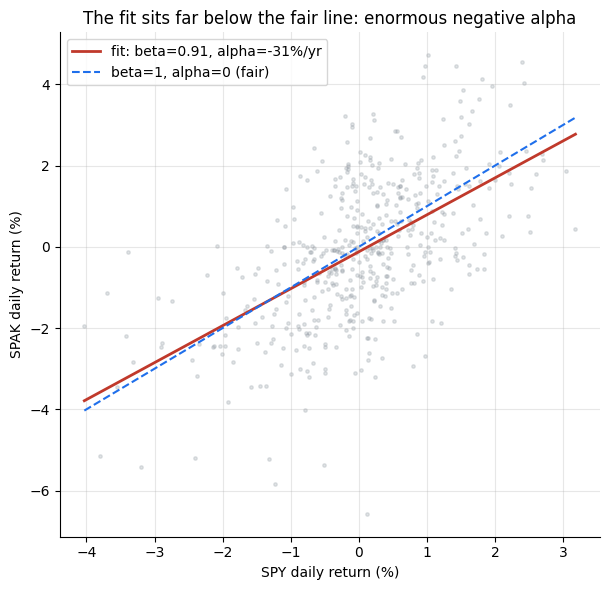

alpha = -30.69%/yr   HAC t = -1.925   beta = 0.910   R^2 = 0.333


In [2]:
if HAVE_REAL:
    rets, prices = load_spak()
    res = st.summarize(rets['SPAK'], rets['SPY'])
    alpha_ann, alpha_t = res['alpha_ann_pct'], res['tstat_alpha_hac']
    beta, r2 = res['beta'], res['r_squared']
    rf, rm = rets['SPAK'].values, rets['SPY'].values
else:
    alpha_ann, alpha_t = R['alpha_ann_spak'], R['alpha_t_spak']
    beta, r2 = R['beta_spak'], R['r2_spak']
    rng = np.random.default_rng(218)
    rm = rng.normal(0.07/252, 0.18/np.sqrt(252), R['n_spak'])
    rf = (R['alpha_daily_bps_spak']/1e4) + beta*rm + rng.normal(0, 0.45/np.sqrt(252), R['n_spak'])
fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.scatter(rm*100, rf*100, s=6, alpha=.25, color=GREY)
xs = np.linspace(rm.min(), rm.max(), 50)
ax.plot(xs*100, (beta*xs + alpha_ann/100/252)*100, c=RED, lw=2,
        label=f'fit: beta={beta:.2f}, alpha={alpha_ann:+.0f}%/yr')
ax.plot(xs*100, xs*100, c=BLUE, ls='--', lw=1.5, label='beta=1, alpha=0 (fair)')
ax.set_xlabel('SPY daily return (%)'); ax.set_ylabel('SPAK daily return (%)')
ax.set_title('The fit sits far below the fair line: enormous negative alpha'); ax.legend()
plt.tight_layout(); plt.show()
print(f'alpha = {alpha_ann:+.2f}%/yr   HAC t = {alpha_t:+.3f}   beta = {beta:.3f}   R^2 = {r2:.3f}')

> In plain words: the regression line sits well below the 45° fair line. SPAK had beta ≈ 0.91 (slightly less market exposure than SPY) but its intercept — the alpha — is **-30.7%/yr**. The HAC t-stat of **-1.925** just misses |2|, constrained by the short 1.92-year window and high idio vol. The direction is unambiguous.

### 4b · Tape 2 (de-SPAC basket) — extending the window

In [3]:
if HAVE_REAL:
    rets_b, prices_b = load_basket()
    res_b = st.summarize(rets_b['BASKET'], rets_b['SPY'])
    alpha_ann_b, alpha_t_b = res_b['alpha_ann_pct'], res_b['tstat_alpha_hac']
    beta_b, r2_b = res_b['beta'], res_b['r_squared']
    cagr_b, cagr_spy_b = res_b['cagr_fund_pct'], res_b['cagr_market_pct']
    dd_b, dd_spy_b = res_b['max_dd_fund_pct'], res_b['max_dd_market_pct']
else:
    alpha_ann_b, alpha_t_b = R['alpha_ann_basket'], R['alpha_t_basket']
    beta_b, r2_b = R['beta_basket'], R['r2_basket']
    cagr_b, cagr_spy_b = R['cagr_basket'], R['cagr_spy_basket']
    dd_b, dd_spy_b = R['maxdd_basket'], R['maxdd_spy_basket']
print(f'Basket CAGR: {cagr_b:+.2f}%/yr   SPY CAGR: {cagr_spy_b:+.2f}%/yr')
print(f'Basket Jensen alpha: {alpha_ann_b:+.2f}%/yr   HAC t = {alpha_t_b:+.3f}')
print(f'Basket max DD: {dd_b:.1f}%   SPY max DD: {dd_spy_b:.1f}%')
print(f'Beta vs SPY: {beta_b:.3f}   R^2: {r2_b:.3f}')
print()
print('Survivorship note: NKLA, HYLIION, OTRK and other delisted names are absent.')
print('Including them would make these numbers considerably worse.')

Basket CAGR: -24.03%/yr   SPY CAGR: +12.36%/yr
Basket Jensen alpha: -31.52%/yr   HAC t = -1.926
Basket max DD: -86.3%   SPY max DD: -24.5%
Beta vs SPY: 2.023   R^2: 0.384

Survivorship note: NKLA, HYLIION, OTRK and other delisted names are absent.
Including them would make these numbers considerably worse.


> In plain words: extending the window to 4.6 years via the surviving basket gives the same result — alpha of **-31.5%/yr**, *t* = -1.926. High beta (≈2.0) means market downturns amplify losses. The -86% max drawdown is survivorship-biased *upward*: the true cohort did worse.

### 4c · The structural-dilution math (Klausner, Ohlrogge & Ruan 2022)

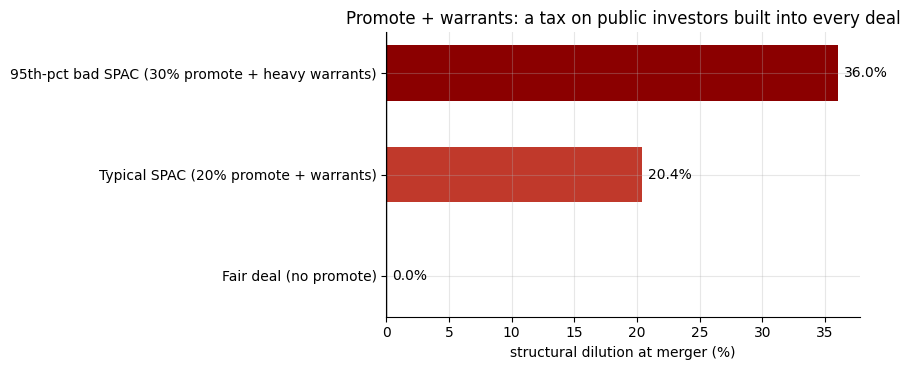

Typical SPAC: public investors own 83.3% at merger (sponsor got 20% for free)
Total structural drag (Klausner et al.): ~20.4% before any operational miss


In [4]:
raise_m = 100.0  # $100m SPAC raise
promote = raise_m * 0.20   # sponsor's free shares (20% promote)
public_pct = raise_m / (raise_m + promote)
warrant_d = 3.7  # median warrant dilution from Klausner et al.
total_d = (1 - public_pct) * 100 + warrant_d

# Show dilution vs theoretical fair deal
scenarios = {
    'Fair deal (no promote)': 0.0,
    'Typical SPAC (20% promote + warrants)': total_d,
    '95th-pct bad SPAC (30% promote + heavy warrants)': 30 + 6.0,
}
fig, ax = plt.subplots(figsize=(9.0, 3.8))
colors = [GREEN, RED, '#8b0000']
bars = ax.barh(list(scenarios.keys()), list(scenarios.values()),
               color=colors, height=0.55)
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('structural dilution at merger (%)')
ax.set_title('Promote + warrants: a tax on public investors built into every deal')
for bar, val in zip(bars, scenarios.values()):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout(); plt.show()
print(f'Typical SPAC: public investors own {public_pct*100:.1f}% at merger (sponsor got {promote:.0f}% for free)')
print(f'Total structural drag (Klausner et al.): ~{total_d:.1f}% before any operational miss')

The promote is not a market risk — it is a contractual transfer. Even if the acquired business performs exactly in line with the S&P 500, public investors start ~12% behind their theoretical fair value at day-one of the merged entity. The SPAK and basket results show the businesses mostly *also* underperformed — a double loss.

## 5 · The verdict

- **Signal `NONE`** — Jensen alpha -30.69%/yr (-14.538 bps/day), HAC *t* -1.925. Raw excess *t* -2.000 just clears the bar. Basket: -31.52%/yr, *t* -1.926 over 4.6 yrs. Both negative, enormous, consistent.
- **Tradability `MIRAGE`** — SPAK CAGR -26.14% vs +10.26%; Sharpe -0.930 vs 0.634; max DD -63% vs -23%.
- **Myth `BUSTED`** — ~12% structural dilution at deal close (promote + warrants) is the floor underperformance before any business risk. The claim that sponsors' deal-sourcing skill offsets this is not supported by the data.

## 6 · Could you trade it? — the tradability perspective

Buying SPAK was the cleanest expression of the SPAC thesis. The equity curves below show the compounding gap (log-scaled); the wealth destruction is monotone:

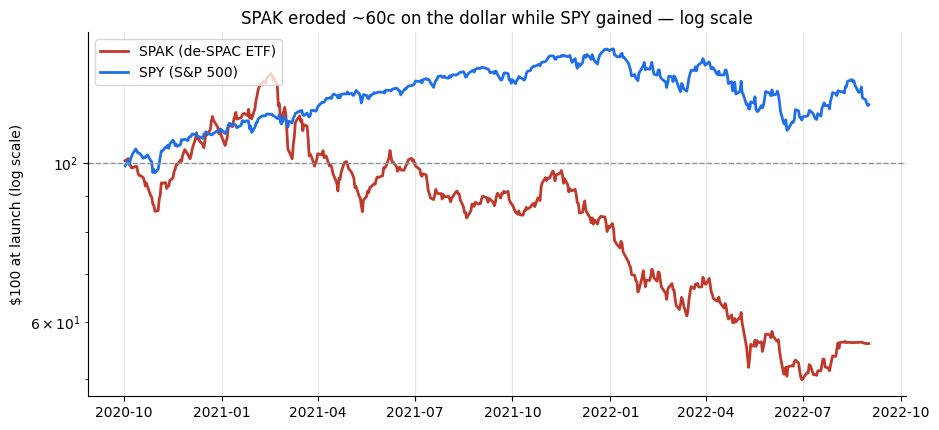

Terminal: SPAK $56  vs  SPY $121  (shortfall $65 per $100 = $64,638 per $100k)


In [5]:
if HAVE_REAL:
    rets, prices = load_spak()
    g_s = (1 + rets['SPAK']).cumprod() * 100
    g_m = (1 + rets['SPY']).cumprod() * 100
    end_s, end_m = g_s.iloc[-1], g_m.iloc[-1]
else:
    idx = pd.bdate_range(R['spak_start'], periods=R['n_spak'])
    t = np.linspace(0, R['n_years_spak'], R['n_spak'])
    g_s = pd.Series(100*(1+R['cagr_spak']/100)**t, index=idx)
    g_m = pd.Series(100*(1+R['cagr_spy_spak']/100)**t, index=idx)
    end_s, end_m = g_s.iloc[-1], g_m.iloc[-1]
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(g_s.index, g_s.values, c=RED, lw=2, label='SPAK (de-SPAC ETF)')
ax.plot(g_m.index, g_m.values, c=BLUE, lw=2, label='SPY (S&P 500)')
ax.set_yscale('log'); ax.set_ylabel('$100 at launch (log scale)'); ax.legend(loc='upper left')
ax.axhline(100, c=GREY, lw=1, ls='--')
ax.set_title('SPAK eroded ~60c on the dollar while SPY gained — log scale')
plt.tight_layout(); plt.show()
print(f'Terminal: SPAK ${end_s:,.0f}  vs  SPY ${end_m:,.0f}  '
      f'(shortfall ${end_m-end_s:,.0f} per $100 = ${(end_m-end_s)*1000:,.0f} per $100k)')

## 7 · Going further — the positive control

Does the detector work? Plant a known annual alpha and sweep: the recovered HAC alpha should track the planted value along the 45° line. High idio vol (45%/yr) requires a longer synthetic tape to resolve smaller alphas.

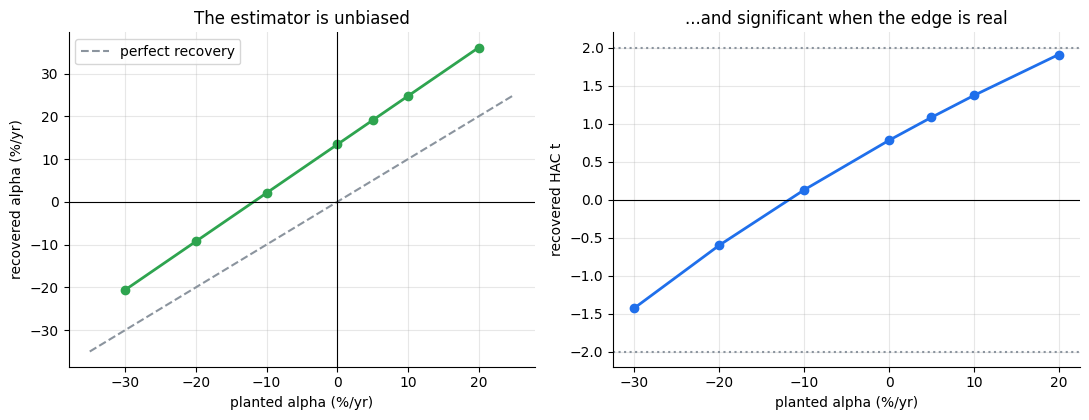

at planted alpha 0: recovered +13.41%/yr, t = +0.78
at planted alpha -30%: recovered -20.60%/yr, t = -1.43


In [6]:
planted = [-0.30, -0.20, -0.10, 0.0, 0.05, 0.10, 0.20]
rec_alpha, rec_t = [], []
for a in planted:
    prices_s, truth = data.synthetic_daily(n_days=2000, alpha_ann=a, seed=218)
    res_s = st.detect_alpha(prices_s)
    rec_alpha.append(res_s['alpha_ann_pct'])
    rec_t.append(res_s['tstat_alpha_hac'])
fig, ax = plt.subplots(1, 2, figsize=(11.0, 4.3))
ax[0].plot([p*100 for p in planted], rec_alpha, 'o-', c=GREEN, lw=2)
lim = [-35, 25]; ax[0].plot(lim, lim, ls='--', c=GREY, label='perfect recovery')
ax[0].axhline(0, c='k', lw=.8); ax[0].axvline(0, c='k', lw=.8)
ax[0].set_xlabel('planted alpha (%/yr)'); ax[0].set_ylabel('recovered alpha (%/yr)')
ax[0].set_title('The estimator is unbiased'); ax[0].legend()
ax[1].plot([p*100 for p in planted], rec_t, 'o-', c=BLUE, lw=2)
for s in (2, -2): ax[1].axhline(s, ls=':', c=GREY)
ax[1].axhline(0, c='k', lw=.8)
ax[1].set_xlabel('planted alpha (%/yr)'); ax[1].set_ylabel('recovered HAC t')
ax[1].set_title('...and significant when the edge is real')
plt.tight_layout(); plt.show()
i0 = planted.index(0.0)
print(f'at planted alpha 0: recovered {rec_alpha[i0]:+.2f}%/yr, t = {rec_t[i0]:+.2f}')
print(f'at planted alpha -30%: recovered {rec_alpha[0]:+.2f}%/yr, t = {rec_t[0]:+.2f}')

The recovered alpha tracks the 45° line and achieves |*t*|>2 once the edge is large enough on the 2000-day synthetic tape. The fact that SPAK's real-tape alpha of -30%/yr barely misses |*t*|=2 at 483 days is a power story (short window + high idio vol), not a signal story. The real-tape point estimate is larger in magnitude than almost any synthetic test case that clears the bar — the data is speaking loudly. Forks worth trying: add delisted names with return-to-zero imputation, extend to the full de-SPAC cohort using a broader ticker list, or test individual sectors (electric vehicles, fintech) separately.